# Headway & Frequency Analysis
Computes wait times between consecutive buses and hourly service frequency from GPS telemetry data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)
import warnings
warnings.filterwarnings('ignore') 

In [8]:
#["all_mob_files = sorted(glob.glob('..\..\data\mobility_data\*.csv'))\nif not all_mob_files:\n    raise FileNotFoundError('No mobility CSVs found.')\n\nfile_to_load = all_mob_files[0]\ndf_mob = pd.read_csv(file_to_load)\ndf_mob['timestamp'] = pd.to_datetime(df_mob['timestamp'])\n\nprint(f'Loaded {len(df_mob):,} records from {os.path.basename(file_to_load)}')\ndisplay(df_mob.head(3))"]
all_mob_files = sorted(glob.glob('../../data/mobility_data/*.csv'))
if not all_mob_files:
    raise FileNotFoundError('No mobility CSVs found.')

df_mob = pd.concat([pd.read_csv(f) for f in all_mob_files], ignore_index=True)

print(f'Loaded {len(df_mob):,} records from {len(all_mob_files)} files')
display(df_mob.head(3))

Loaded 13,553,096 records from 19 files


,id,timestamp,tripId,lat,lng,heading,lineId,lineName,headsign,direction
0,52243,2026-03-11 00:00:07,1476582_U_37,-22.875029,-43.038486,322.00000,52,BALDEADOR X ITAIPU (VIA CANTAGALO),52 BALDEADOR,1
1,52272,2026-03-11 00:00:07,1483711_U_195,-22.912451,-43.078884,92.60256,33,JURUJUBA X TERMINAL RODOVIARIO,33 TERMINAL RODOVIÁRIO,0
2,69020,2026-03-11 00:00:07,1345046_U_36,-22.890236,-43.124805,352.20000,39A,PIRATININGA X CENTRO,39A Piratininga (Cafubá),1


In [17]:
df_mob['timestamp'] = pd.to_datetime(df_mob['timestamp'])

In [9]:
df_clean = df_mob.dropna(subset=['lineId', 'direction', 'tripId', 'id']).copy()
df_clean = df_clean.sort_values(by=['lineId', 'direction', 'id', 'timestamp'])
print(f"Records after cleaning: {len(df_clean):,}")

Records after cleaning: 13,553,096


In [24]:
trip_starts = df_clean.groupby(['lineId', 'direction', 'tripId', 'id'])['timestamp'].min().reset_index()
trip_starts = trip_starts.rename(columns={'timestamp': 'trip_start_time'})
trip_starts['trip_start_time'] = pd.to_datetime(trip_starts['trip_start_time'])
trip_starts = trip_starts.sort_values(by=['lineId', 'direction', 'trip_start_time'])

trip_starts['headway_timedelta'] = trip_starts.groupby(['lineId', 'direction'])['trip_start_time'].diff()
trip_starts['headway_minutes'] = trip_starts['headway_timedelta'].dt.total_seconds() / 60

valid_headways = trip_starts[(trip_starts['headway_minutes'] > 0) & (trip_starts['headway_minutes'] <= 120)].copy()
valid_headways

,lineId,direction,tripId,id,trip_start_time,headway_timedelta,headway_minutes
251,15,0,1348037_U_9,97136,2026-03-11 06:00:28,0 days 00:13:01,13.016667
128,15,0,1348037_U_3,97135,2026-03-11 06:25:59,0 days 00:25:31,25.516667
49,15,0,1348037_U_10,97136,2026-03-11 06:44:00,0 days 00:18:01,18.016667
177,15,0,1348037_U_4,97135,2026-03-11 07:19:02,0 days 00:35:02,35.033333
51,15,0,1348037_U_11,97136,2026-03-11 07:39:03,0 days 00:20:01,20.016667
...,...,...,...,...,...,...,...
37313,OC3A,1,1350109_D_2,72733,2026-03-23 01:23:31,0 days 00:53:34,53.566667
37318,OC3A,1,1350109_D_4,72734,2026-03-23 02:10:17,0 days 00:46:46,46.766667
37311,OC3A,1,1350109_D_1,72742,2026-03-30 00:23:20,0 days 00:21:00,21.000000
37319,OC3A,1,1350109_D_4,72750,2026-03-30 02:16:26,0 days 01:53:06,113.100000


In [25]:
valid_headways['hour'] = valid_headways['trip_start_time'].dt.floor('h')

reliability_df = valid_headways.groupby(['lineId', 'direction', 'hour'])['headway_minutes'].agg(
    mean_hw='mean', std_hw='std', trip_count='count'
).reset_index()
reliability_df = reliability_df[reliability_df['trip_count'] >= 3]
reliability_df['cv'] = reliability_df['std_hw'] / reliability_df['mean_hw']
reliability_df['bunching_risk'] = reliability_df['cv'] > 0.5

worst_routes = reliability_df.sort_values(by='cv', ascending=False).head(10)
display(worst_routes[['lineId', 'direction', 'hour', 'mean_hw', 'cv', 'bunching_risk']])

,lineId,direction,hour,mean_hw,cv,bunching_risk
1873,30.0,0,2026-03-29 00:00:00,7.118519,2.426949,True
7997,45,1,2026-03-30 17:00:00,14.814583,2.157091,True
9682,49.2,0,2026-03-30 17:00:00,14.701667,2.068615,True
9113,49.1,0,2026-03-30 17:00:00,19.571429,1.984856,True
9802,49.2,1,2026-03-16 11:00:00,5.857843,1.975930,True
9696,49.2,0,2026-03-31 16:00:00,5.442222,1.928965,True
13908,OC3,1,2026-03-11 18:00:00,6.484848,1.912274,True
4029,36,0,2026-03-24 13:00:00,8.174074,1.845911,True
10583,53,1,2026-03-26 07:00:00,13.516667,1.827674,True
13274,OC2,0,2026-03-13 14:00:00,23.208333,1.799689,True


Busiest route: 49.2 (Direction 0)
Total trips: 1228
Hourly frequency:
hour_of_day
0       3
1       0
2       0
3       0
4       0
5      16
6      72
7      78
8      55
9      62
10     46
11     54
12     56
13     68
14     69
15     78
16    120
17    115
18    112
19     81
20     62
21     39
22     25
23     17
dtype: int64


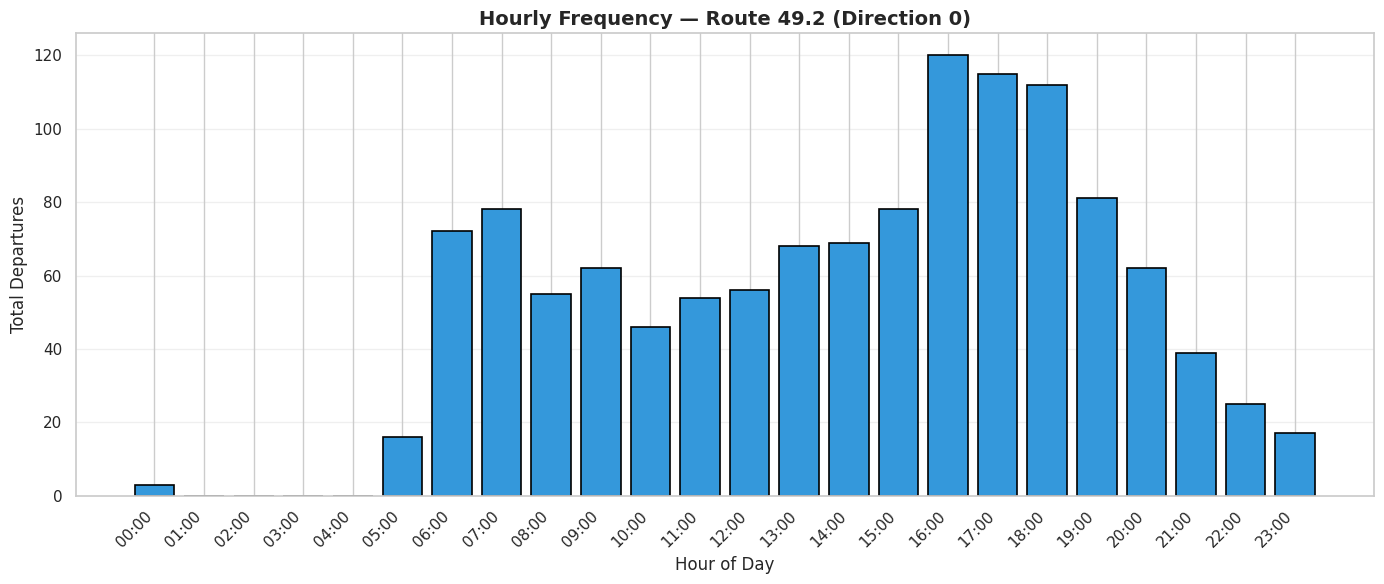

In [29]:
busiest_route = valid_headways.groupby(['lineId', 'direction']).size().idxmax()
target_lineId, target_direction = busiest_route

# Ensure trip_start_time is datetime
valid_headways['trip_start_time'] = pd.to_datetime(valid_headways['trip_start_time'])

# Filter for busiest route
route_trips = valid_headways[
    (valid_headways['lineId'] == target_lineId) &
    (valid_headways['direction'] == target_direction)
].copy()

# Extract HOUR OF DAY (0-23) and group by it
route_trips['hour_of_day'] = route_trips['trip_start_time'].dt.hour
hourly_frequency = route_trips.groupby('hour_of_day').size()

# Fill missing hours with 0
hourly_frequency = hourly_frequency.reindex(range(24), fill_value=0)

print(f'Busiest route: {target_lineId} (Direction {target_direction})')
print(f'Total trips: {len(route_trips)}')
print(f'Hourly frequency:\n{hourly_frequency}')

plt.figure(figsize=(14, 6))
bars = plt.bar(hourly_frequency.index, hourly_frequency.values, color='#3498db', edgecolor='black', linewidth=1.2, width=0.8)
plt.title(f'Hourly Frequency — Route {target_lineId} (Direction {target_direction})', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Total Departures')
plt.xticks(range(0, 24), [f'{h:02d}:00' for h in range(24)], rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

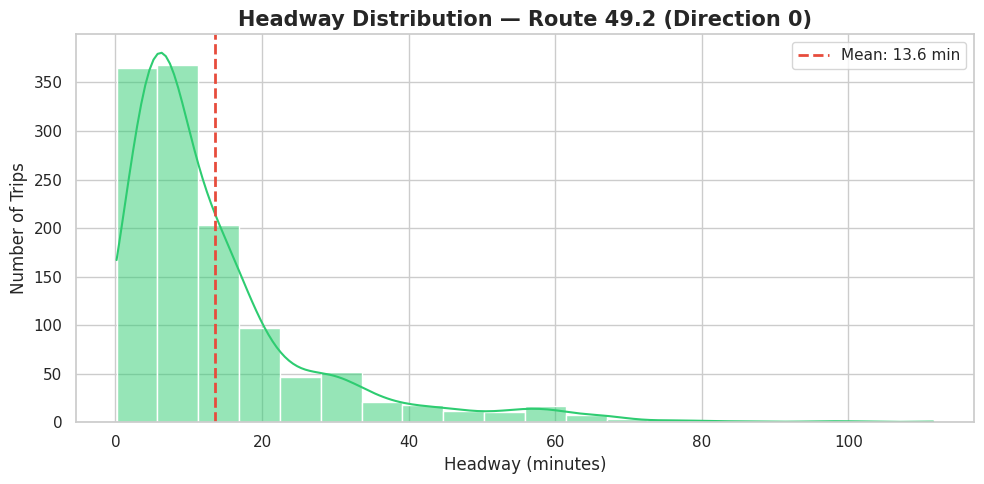

In [30]:
# Headway distribution plot for the busiest route
df_plot = valid_headways[
    (valid_headways['lineId'] == target_lineId) &
    (valid_headways['direction'] == target_direction)
]

plt.figure(figsize=(10, 5))
sns.histplot(df_plot['headway_minutes'], bins=20, kde=True, color='#2ecc71')
mean_val = df_plot['headway_minutes'].mean()
plt.axvline(mean_val, color='#e74c3c', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.1f} min')
plt.title(f'Headway Distribution — Route {target_lineId} (Direction {target_direction})', fontsize=15, fontweight='bold')
plt.xlabel('Headway (minutes)')
plt.ylabel('Number of Trips')
plt.legend()
plt.tight_layout()
plt.show()